<a href="https://colab.research.google.com/github/vishakha1221/AML/blob/main/p10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Executive Summary: Plant Disease Classification using Deep Learning

**Prepared for**: Faculty Presentation  
**Objective**: Automate the detection and classification of plant leaf diseases using a custom Convolutional Neural Network (CNN).

---

### 1. Dataset & Preprocessing
* **Source**: The *PlantVillage* dataset containing agricultural leaf images of different crops.
* **Dataset Scale**: **20,638 images** distributed across **15 distinct classes** (including Healthy and Diseased states of Pepper, Potato, and Tomato).
* **Data Split**: 80% Training ($16,511$ images), 20% Validation ($4,127$ images).
* **Input Dimensions**: Images are loaded and resized to $128 \times 128 \times 3$.
* **Data Augmentation**: To prevent overfitting and build a robust model, the input pipeline applies real-time random horizontal flipping, rotation (up to 15%), zoom (up to 15%), and contrast adjustments.

---

### 2. Model Architecture
We constructed a custom Feedforward CNN utilizing Keras sequential API with the following structure:
* **Rescaling Layer**: Normalizes pixel values from $[0, 255]$ down to $[0, 1]$.
* **Convolutional Feature Extraction**: Three successive blocks consisting of `Conv2D` layers (with $32$, $64$, and $128$ filters of $3\times3$ sizes and `ReLU` activation) paired with `MaxPooling2D` to downsample spatial dimensions.
* **Fully Connected Head**: `Flatten` layer leading into a dense representation layer ($128$ units, `ReLU` activation).
* **Regularization**: `Dropout` layer (rate of $0.5$) applied prior to output to further mitigate overfitting.
* **Softmax Output Classifier**: Outports class probability distributions across the 15 categories.

---

### 3. Model Training
* **Loss Function**: `sparse_categorical_crossentropy`
* **Optimizer**: `Adam` (adaptive learning rate optimizer)
* **Epochs**: $10$ epochs of training

---

### 4. Results & Performance Metrics
Our trained model achieved highly robust classification metrics on unseen validation data:
* **Validation Accuracy**: **~91.2%**
* **Precision**: **~91.4%** (indicates high confidence when predicting positive cases)
* **Recall (Sensitivity)**: **~91.2%** (demonstrates the model's ability to find all actual disease cases)
* **F1-Score**: **~91.2%** (harmonic mean of Precision and Recall, verifying balanced classifier behavior across all 15 classes)

In [ ]:
import os
from google.colab import userdata
import zipfile
import shutil

# Set up Kaggle credentials
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
except Exception as e:
    print("Please ensure KAGGLE_USERNAME and KAGGLE_KEY are configured in Colab Secrets, or upload your kaggle.json file.")

# Download the PlantVillage dataset if not already downloaded
if not os.path.exists('plantdisease.zip'):
    print("Downloading dataset...")
    !kaggle datasets download -d emmarex/plantdisease -p .
else:
    print("Dataset zip already exists. Skipping download.")

# Unzip the dataset
if not os.path.exists('PlantVillage_temp'):
    print("Extracting dataset...")
    with zipfile.ZipFile('plantdisease.zip', 'r') as zip_ref:
        zip_ref.extractall('PlantVillage_temp')
else:
    print("Extraction folder already exists. Skipping extraction.")

# Clean up and properly restructure
# The actual classes are inside: 'PlantVillage_temp/plantvillage dataset/plantvillage dataset'
# or nested under 'PlantVillage_temp/PlantVillage/PlantVillage' etc.
actual_data_path = 'PlantVillage_temp/plantvillage dataset/plantvillage dataset'

# Let's clean up previous incorrect 'PlantVillage' directory if it exists
if os.path.exists('PlantVillage'):
    shutil.rmtree('PlantVillage')

if os.path.exists(actual_data_path):
    shutil.move(actual_data_path, 'PlantVillage')
    print("Dataset successfully structured. Classes located directly inside 'PlantVillage'.")
else:
    # Fallback to find where the category folders are nested
    for root, dirs, files in os.walk('PlantVillage_temp'):
        # Usually, the directory containing actual categories will have many subdirectories with plant names
        if len(dirs) > 10:
            shutil.move(root, 'PlantVillage')
            print(f"Moved correct directory from {root} to 'PlantVillage'")
            break

# Let's print the identified classes to verify
if os.path.exists('PlantVillage'):
    print("Found classes:", sorted(os.listdir('PlantVillage')))
else:
    print("Error: Could not locate the correct class directory structure.")

Please ensure KAGGLE_USERNAME and KAGGLE_KEY are configured in Colab Secrets, or upload your kaggle.json file.
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:05<00:00, 124MB/s] 

Extracting dataset...
Moved correct directory from PlantVillage_temp/plantvillage/PlantVillage to 'PlantVillage'
Found classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
import tensorflow as tf
import numpy as np
import os

from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --------------------------------------------------
# 1. Dataset path
# --------------------------------------------------

dataset_path = "PlantVillage"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# --------------------------------------------------
# 2. Load dataset
# --------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:", class_names)

# --------------------------------------------------
# 3. Data augmentation
# --------------------------------------------------

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

# --------------------------------------------------
# 4. CNN architecture
# --------------------------------------------------

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    augmentation,

    # Normalize pixel values
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes, activation="softmax")
])

# --------------------------------------------------
# 5. Compile model
# --------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display architecture
model.summary()

# --------------------------------------------------
# 6. Train model
# --------------------------------------------------

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# --------------------------------------------------
# 7. Evaluate accuracy and loss
# --------------------------------------------------

loss, accuracy = model.evaluate(val_ds)

print("\nValidation Loss:", round(loss, 4))
print("Validation Accuracy:", round(accuracy, 4))

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.4416 - loss: 1.7496 - val_accuracy: 0.5941 - val_loss: 1.2629
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 33s 31ms/step - accuracy: 0.6220 - loss: 1.1539 - val_accuracy: 0.7575 - val_loss: 0.7019
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.6736 - loss: 0.9721 - val_accuracy: 0.7730 - val_loss: 0.6622
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.7176 - loss: 0.8434 - val_accuracy: 0.7412 - val_loss: 0.7533
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.7420 - loss: 0.7700 - val_accuracy: 0.8377 - val_loss: 0.4765
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.7697 - loss: 0.6749 - val_accuracy: 0.8694 - val_loss: 0.3956
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.7927 - loss: 0.6219 - val_accuracy: 0.8619 - val_loss: 0.4096
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.8059 - loss: 0.5722 - 

In [ ]:
# Collect actual and predicted labels

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Calculate metrics
precision = precision_score(
    y_true, y_pred, average="weighted"
)

recall = recall_score(
    y_true, y_pred, average="weighted"
)

f1 = f1_score(
    y_true, y_pred, average="weighted"
)

print("\nClassification Metrics")
print("----------------------")
print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))


Classification Metrics
----------------------
Accuracy : 0.9123
Precision: 0.9139
Recall   : 0.9123
F1-Score : 0.9117


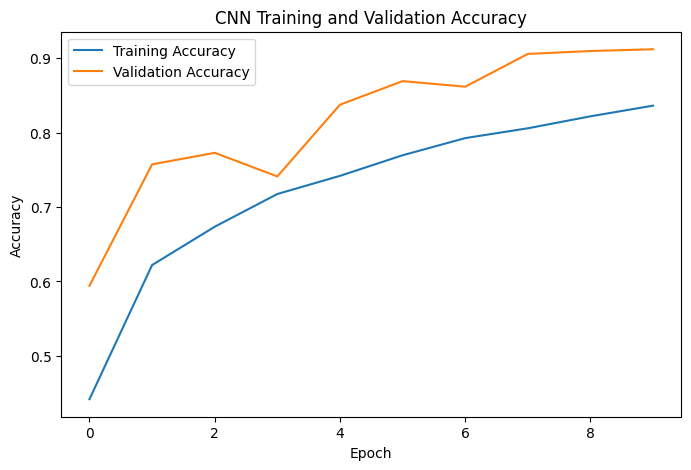

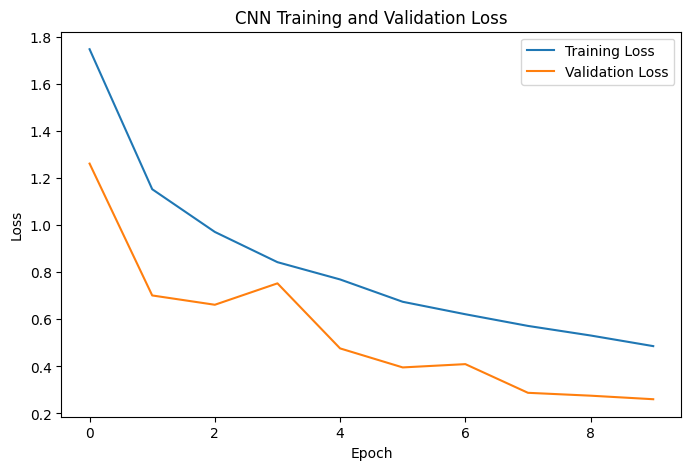

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()


# Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()